# LSTM - Model

### Import dependencies
- Import libraries for:
  - Data processing (`pandas`, `numpy`)
  - Evaluation metrics from `sklearn`
  - Deep learning with `tensorflow.keras` (LSTM layers, optimizers, callbacks)
- Load tools for handling class imbalance, model training, and performance tracking.


In [1341]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import classification_report
from sklearn.utils import class_weight

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf
tf.config.run_functions_eagerly(True)

### Load and prepare dataset
- Load the VIF-normalized macroeconomic dataset from Excel.
- Convert the `date` column to datetime format for later slicing.
- Initialize a container to store results for each model run.


In [1343]:
data_path = "../data/datasets/panel_dataset_VIF_normalized.xlsx"
df = pd.read_excel(data_path)
df['date'] = pd.to_datetime(df['date'])

all_results = []

### Initial setup
- Set the target to predict (`RECESS`, `RECESS_OVER`, or `RECESS_PERIOD`)
- Define which columns to exclude from the feature set (`date`, `Country`, all targets)
- `feature_cols` will include all remaining predictors

In [1344]:
TARGETS = ['RECESS', 'RECESS_OVER', 'RECESS_PERIOD']
target_name = "RECESS"
exclude_cols = ['date', 'Country'] + TARGETS
feature_cols = [col for col in df.columns if col not in exclude_cols]

### Clean and encode data
- Drop rows with missing values in either feature or target columns
- Encode countries as numeric IDs using `LabelEncoder` for modeling
- Sort the dataset by country and date for correct sequence construction

In [1345]:
df.dropna(subset=feature_cols + TARGETS, inplace=True)
df['country_id'] = LabelEncoder().fit_transform(df['Country'])
if 'country_id' not in feature_cols:
    feature_cols.append('country_id')
df.sort_values(['Country', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)

### Early Stopping Configuration
- Configure early stopping to monitor validation loss
- Training will halt early if no improvement is seen after 10 epochs


In [1346]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

### Set time-based split ranges
- Define start and end dates for training, validation, and test periods

In [1347]:
train_start = "1995-01-01"
train_end = "2009-12-31"
val_start = "2010-01-01"
val_end = "2018-12-31"
test_start = "2019-01-01"
test_end = "2024-05-31"

### Apply time-based splits
- Subset the dataset into train, validation, and test based on `date` column

In [1348]:
df_train = df[(df['date'] >= train_start) & (df['date'] <= train_end)].copy()
df_val = df[(df['date'] >= val_start) & (df['date'] <= val_end)].copy()
df_test = df[(df['date'] >= test_start) & (df['date'] <= test_end)].copy()

### Set sliding window size
- Define the number of past time steps (`time_steps = 24`) to include in each input sequence

In [1349]:
time_steps = 24

### Build training sequences
- For each country:
  - Use a rolling window to build sequences of 24 months of features
  - Use the 25th month as the target

In [1350]:
X_train, y_train = [], []
for _, group in df_train.groupby('Country'):
    group = group.sort_values('date').reset_index(drop=True)
    for i in range(len(group) - time_steps):
        X_train.append(group.loc[i:i+time_steps-1, feature_cols].values)
        y_train.append(group.loc[i+time_steps, target_name])

X_train = np.array(X_train)
y_train = np.array(y_train)


### Build validation sequences
- Same as training: use 24 months of input features and the next month as label


In [1351]:
X_val, y_val = [], []
for _, group in df_val.groupby('Country'):
    group = group.sort_values('date').reset_index(drop=True)
    for i in range(len(group) - time_steps):
        X_val.append(group.loc[i:i+time_steps-1, feature_cols].values)
        y_val.append(group.loc[i+time_steps, target_name])

X_val = np.array(X_val)
y_val = np.array(y_val)

### Build test sequences
- Repeat the rolling window process to prepare test inputs and labels

In [1352]:
X_test, y_test = [], []
for _, group in df_test.groupby('Country'):
    group = group.sort_values('date').reset_index(drop=True)
    for i in range(len(group) - time_steps):
        X_test.append(group.loc[i:i+time_steps-1, feature_cols].values)
        y_test.append(group.loc[i+time_steps, target_name])

X_test = np.array(X_test)
y_test = np.array(y_test)

### Show split sizes
- Print how many sequences were created for training, validation, and testing


In [1353]:
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Train: 686 samples
Validation: 504 samples
Test: 240 samples


### Compute class weights
- Calculate balanced class weights to address class imbalance in binary classification
- This helps the model not ignore underrepresented recession periods

In [1354]:
# Calculate class weights for the current target
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), class_weights))
print(f"Class weights for {target_name}:", class_weights)

Class weights for RECESS: {np.int64(0): np.float64(0.7538461538461538), np.int64(1): np.float64(1.4848484848484849)}


### Define standard LSTM model
- Build a single-layer LSTM model with dropout and a sigmoid output
- Compile using binary crossentropy and RMSprop optimizer

In [1355]:
model = Sequential()
model.add(LSTM(16, recurrent_dropout= 0.2, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.45))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer=RMSprop(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Train standard LSTM model
- Fit the model with training data and evaluate using validation data
- Apply class weights and early stopping

In [1356]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
    class_weight=class_weights
)

Epoch 1/100


C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 335ms/step - accuracy: 0.4790 - loss: 0.7056 - val_accuracy: 0.5734 - val_loss: 0.6948
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 459ms/step - accuracy: 0.5012 - loss: 0.6973 - val_accuracy: 0.5694 - val_loss: 0.6933
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 424ms/step - accuracy: 0.5506 - loss: 0.6767 - val_accuracy: 0.5655 - val_loss: 0.6928
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 399ms/step - accuracy: 0.5496 - loss: 0.6922 - val_accuracy: 0.5556 - val_loss: 0.6918
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 400ms/step - accuracy: 0.5158 - loss: 0.6877 - val_accuracy: 0.5437 - val_loss: 0.6908
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 411ms/step - accuracy: 0.5964 - loss: 0.6754 - val_accuracy: 0.5278 - val_loss: 0.6903
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 403ms/step - accuracy: 0.5207 - loss: 0.7022 - val_accuracy: 0.5278 - val_loss: 0.6892
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 414ms/step - accuracy: 0.5631 - loss: 0.6737 - val_accuracy: 0.539

### Tune threshold using validation set
- Predict probabilities on the validation set
- Loop through thresholds (0.1 to 0.9) to find the best F1 score

In [1357]:
y_pred_val = model.predict(X_val).flatten()

best_thresh = 0.5
best_f1 = 0

for t in np.arange(0.1, 0.91, 0.01):
    y_pred_bin = (y_pred_val >= t).astype(int)
    f1 = f1_score(y_val, y_pred_bin)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"[VALIDATION] Best threshold = {best_thresh:.2f} | Best F1 = {best_f1:.4f}")

 1/16 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step
[VALIDATION] Best threshold = 0.23 | Best F1 = 0.7209


### Visualize training history
- Plot loss curves for training and validation sets

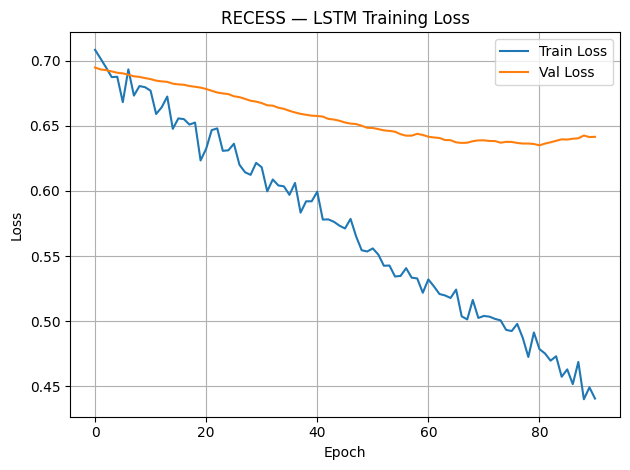

In [1358]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{target_name} — LSTM Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Predict on test set using tuned threshold
- Apply the best threshold to binarize predictions

In [1359]:
y_pred_test = model.predict(X_test).flatten()
y_pred_std_test = (y_pred_test >= best_thresh).astype(int)

1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step


### Evaluate standard LSTM
- Print classification report and compute AUC, F1, precision, recall, accuracy
- Display results in a consistent format

In [1360]:
print(classification_report(y_test, y_pred_std_test))

              precision    recall  f1-score   support

           0       1.00      0.11      0.19       215
           1       0.12      1.00      0.21        25

    accuracy                           0.20       240
   macro avg       0.56      0.55      0.20       240
weighted avg       0.91      0.20      0.19       240



In [1361]:
auc = roc_auc_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_std_test)
recall = recall_score(y_test, y_pred_std_test)
f1 = f1_score(y_test, y_pred_std_test)
accuracy = accuracy_score(y_test, y_pred_std_test)

### Log results: Standard LSTM
- Append performance metrics to the `all_results` list for this model

In [1362]:
print(f"[RESULTS] {target_name} — Sequential LSTM")
print(f"AUC:       {auc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Threshold: {best_thresh}")


[RESULTS] RECESS — Sequential LSTM
AUC:       0.7380
F1 Score:  0.2066
Precision: 0.1152
Recall:    1.0000
Accuracy:  0.2000
Threshold: 0.22999999999999995


In [1363]:
all_results.append({
    "Model": "Sequential LSTM",
    "Target": target_name,
    "AUC": auc,
    "F1": f1,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "Threshold": best_thresh
})


### Define Bidirectional LSTM model
- Build a bidirectional LSTM followed by dropout and dense layer
- Use same optimizer and loss as standard LSTM

In [1364]:
model_bi = Sequential()
model_bi.add(Bidirectional(LSTM(16, recurrent_dropout= 0.2,  return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])))
model_bi.add(Dropout(0.45))
model_bi.add(Dense(1, activation='sigmoid'))
model_bi.compile(optimizer=RMSprop(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Train Bidirectional LSTM model
- Fit the model with early stopping and class weights

In [1365]:
history_bi = model_bi.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
    class_weight=class_weights
)

Epoch 1/100


C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 600ms/step - accuracy: 0.4173 - loss: 0.7353 - val_accuracy: 0.3829 - val_loss: 0.7810
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 592ms/step - accuracy: 0.4307 - loss: 0.7332 - val_accuracy: 0.3810 - val_loss: 0.7768
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 591ms/step - accuracy: 0.5064 - loss: 0.7018 - val_accuracy: 0.3750 - val_loss: 0.7730
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 592ms/step - accuracy: 0.5138 - loss: 0.6877 - val_accuracy: 0.3671 - val_loss: 0.7687
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 598ms/step - accuracy: 0.5107 - loss: 0.7178 - val_accuracy: 0.3710 - val_loss: 0.7643
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 595ms/step - accuracy: 0.5381 - loss: 0.6923 - val_accuracy: 0.3889 - val_loss: 0.7612
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 601ms/step - accuracy: 0.5275 - loss: 0.6849 - val_accuracy: 0.4286 - val_loss: 0.7570
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 592ms/step - accuracy: 0.5772 - loss: 0.6726 - val_accuracy

### Tune threshold (Bidirectional LSTM)
- Predict on validation set and find best threshold for F1 score

In [1366]:
y_pred_val = model_bi.predict(X_val).flatten()

best_thresh = 0.5
best_f1 = 0

for t in np.arange(0.1, 0.91, 0.01):
    y_pred_bin = (y_pred_val >= t).astype(int)
    f1 = f1_score(y_val, y_pred_bin)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"[VALIDATION] Best threshold = {best_thresh:.2f} | Best F1 = {best_f1:.4f}")

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 291ms/step
[VALIDATION] Best threshold = 0.30 | Best F1 = 0.6558


### Plot training history (Bidirectional LSTM)
- Visualize train vs. val loss curves

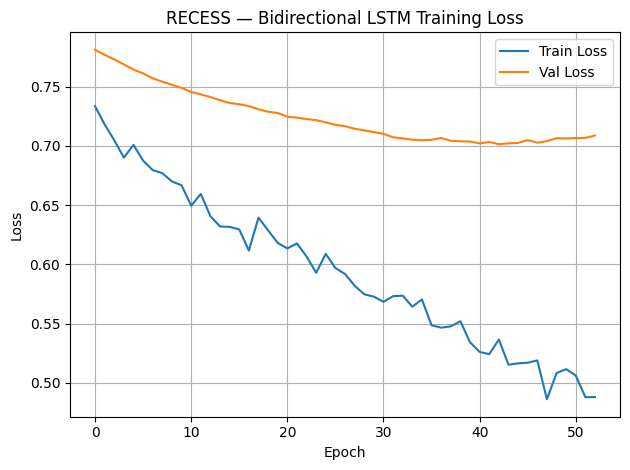

In [1367]:
plt.plot(history_bi.history['loss'], label='Train Loss')
plt.plot(history_bi.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{target_name} — Bidirectional LSTM Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Predict and evaluate Bidirectional LSTM
- Generate test predictions, binarize using best threshold
- Print classification report and metrics

In [1368]:
y_pred_test = model_bi.predict(X_test).flatten()
y_pred_bin_test = (y_pred_test >= best_thresh).astype(int)

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step


### Predict and evaluate Bidirectional LSTM
- Generate test predictions, binarize using best threshold
- Print classification report and metrics

In [1369]:
print(classification_report(y_test, y_pred_bin_test))

              precision    recall  f1-score   support

           0       1.00      0.08      0.15       215
           1       0.11      1.00      0.20        25

    accuracy                           0.18       240
   macro avg       0.56      0.54      0.18       240
weighted avg       0.91      0.18      0.16       240



### Model performance

In [1370]:
auc_bi = roc_auc_score(y_test, y_pred_test)  # still use probabilities
precision_bi = precision_score(y_test, y_pred_bin_test)
recall_bi = recall_score(y_test, y_pred_bin_test)
f1_bi = f1_score(y_test, y_pred_bin_test)
accuracy_bi = accuracy_score(y_test, y_pred_bin_test)

### Log results: Bidirectional LSTM
- Save all performance metrics to `all_results`

In [1371]:
print(f"[RESULTS] {target_name} — Bidirectional LSTM")
print(f"AUC:       {auc_bi:.4f}")
print(f"F1 Score:  {f1_bi:.4f}")
print(f"Precision: {precision_bi:.4f}")
print(f"Recall:    {recall_bi:.4f}")
print(f"Accuracy:  {accuracy_bi:.4f}")
print(f"Threshold: {best_thresh}")

[RESULTS] RECESS — Bidirectional LSTM
AUC:       0.4188
F1 Score:  0.2024
Precision: 0.1126
Recall:    1.0000
Accuracy:  0.1792
Threshold: 0.29999999999999993


### Adding to the results dataframe

In [1372]:
all_results.append({
    "Model": "Bidirectional LSTM",
    "Target": target_name,
    "AUC": auc_bi,
    "F1": f1_bi,
    "Precision": precision_bi,
    "Recall": recall_bi,
    "Accuracy": accuracy_bi,
    "Threshold": best_thresh
})

### Define Stacked LSTM model
- Stack two LSTM layers with dropout in between
- Final dense layer for binary classification

In [1373]:
model_stacked = Sequential()
model_stacked.add(LSTM(16, recurrent_dropout= 0.1, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model_stacked.add(Dropout(0.4))
model_stacked.add(LSTM(16, recurrent_dropout= 0.1, return_sequences=False))
model_stacked.add(Dropout(0.5))
model_stacked.add(Dense(1, activation='sigmoid'))
model_stacked.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Train Stacked LSTM model
- Train the stacked architecture using same settings

In [1374]:
history_stacked = model_stacked.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
    class_weight=class_weights
)

Epoch 1/100


C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 915ms/step - accuracy: 0.4454 - loss: 0.7137 - val_accuracy: 0.4365 - val_loss: 0.7168
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 811ms/step - accuracy: 0.4212 - loss: 0.7172 - val_accuracy: 0.4385 - val_loss: 0.7115
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 818ms/step - accuracy: 0.4528 - loss: 0.7061 - val_accuracy: 0.4385 - val_loss: 0.7067
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 808ms/step - accuracy: 0.4841 - loss: 0.7176 - val_accuracy: 0.4425 - val_loss: 0.7023
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 806ms/step - accuracy: 0.4799 - loss: 0.7083 - val_accuracy: 0.5079 - val_loss: 0.6974
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 814ms/step - accuracy: 0.5286 - loss: 0.6836 - val_accuracy: 0.5397 - val_loss: 0.6934
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 900ms/step - accuracy: 0.5254 - loss: 0.7092 - val_accuracy: 0.5655 - val_loss: 0.6893
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 897ms/step - accuracy: 0.5295 - loss: 0.6984 - val_accuracy

### Tune threshold (Stacked LSTM)
- Loop over thresholds to find best one for F1 score on validation set

In [1375]:
y_pred_val = model_stacked.predict(X_val).flatten()

best_thresh = 0.5
best_f1 = 0

for t in np.arange(0.1, 0.91, 0.01):
    y_pred_bin = (y_pred_val >= t).astype(int)
    f1 = f1_score(y_val, y_pred_bin)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"[VALIDATION] Best threshold = {best_thresh:.2f} | Best F1 = {best_f1:.4f}")

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 304ms/step
[VALIDATION] Best threshold = 0.31 | Best F1 = 0.7552


### Plot training history (Stacked LSTM)
- Display loss curves for the stacked model

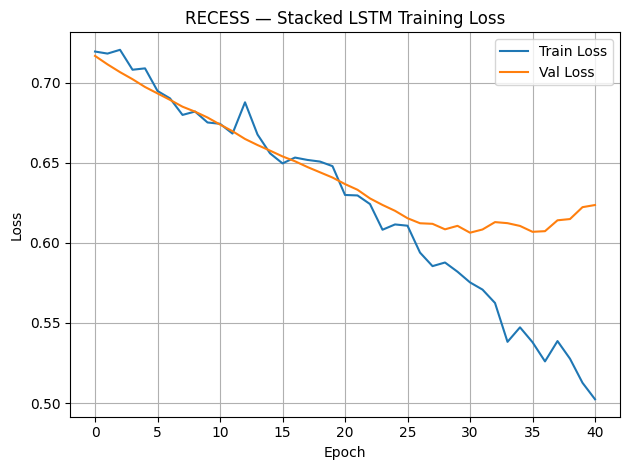

In [1376]:
plt.plot(history_stacked.history['loss'], label='Train Loss')
plt.plot(history_stacked.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{target_name} — Stacked LSTM Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Predict and evaluate Stacked LSTM
- Apply tuned threshold and evaluate test predictions
- Compute classification metrics and print them

In [1377]:
y_pred_test = model_stacked.predict(X_test).flatten()
y_pred_stacked_test = (y_pred_test >= best_thresh).astype(int)

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 333ms/step


### Performance

In [1378]:
print(classification_report(y_test, y_pred_stacked_test))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       215
           1       0.10      1.00      0.19        25

    accuracy                           0.10       240
   macro avg       0.05      0.50      0.09       240
weighted avg       0.01      0.10      0.02       240



C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

In [1379]:
auc_bi = roc_auc_score(y_test, y_pred_test)  # still use probabilities
precision_bi = precision_score(y_test, y_pred_stacked_test)
recall_bi = recall_score(y_test, y_pred_stacked_test)
f1_bi = f1_score(y_test, y_pred_stacked_test)
accuracy_bi = accuracy_score(y_test, y_pred_stacked_test)

### Log results: Stacked LSTM
- Append performance metrics to the `all_results` list

In [1380]:
print(f"[RESULTS] {target_name} — Stacked LSTM")
print(f"AUC:       {auc_bi:.4f}")
print(f"F1 Score:  {f1_bi:.4f}")
print(f"Precision: {precision_bi:.4f}")
print(f"Recall:    {recall_bi:.4f}")
print(f"Accuracy:  {accuracy_bi:.4f}")
print(f"Threshold: {best_thresh}")


[RESULTS] RECESS — Stacked LSTM
AUC:       0.4750
F1 Score:  0.1887
Precision: 0.1042
Recall:    1.0000
Accuracy:  0.1042
Threshold: 0.30999999999999994


In [1381]:
all_results.append({
    "Model": "Stacked LSTM",
    "Target": target_name,
    "AUC": auc_bi,
    "F1": f1_bi,
    "Precision": precision_bi,
    "Recall": recall_bi,
    "Accuracy": accuracy_bi,
    "Threshold": best_thresh
})

### Compare predictions across LSTM models
- Plot binary predictions from all three models against actual labels
- Helps visually assess overlap or divergence between models

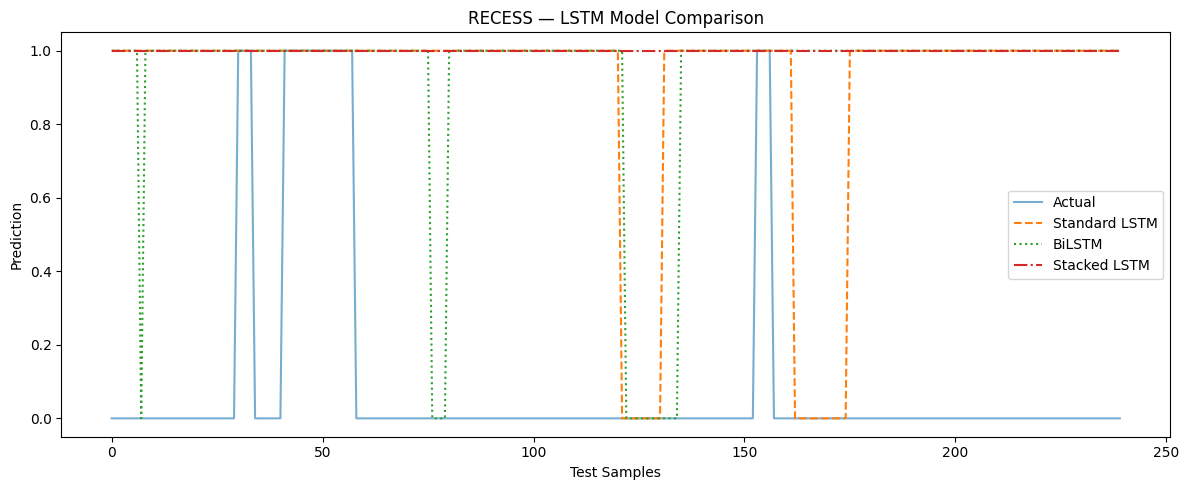

In [1382]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual', alpha=0.6)
plt.plot(y_pred_std_test, label='Standard LSTM', linestyle='--')
plt.plot(y_pred_bin_test, label='BiLSTM', linestyle=':')
plt.plot(y_pred_stacked_test, label='Stacked LSTM', linestyle='-.')
plt.title(f"{target_name} — LSTM Model Comparison")
plt.xlabel("Test Samples")
plt.ylabel("Prediction")
plt.legend()
plt.tight_layout()
plt.show()

### Convert results to DataFrame
- Create a DataFrame from `all_results` for comparison

In [1383]:
results_df = pd.DataFrame(all_results)
results_df

,Model,Target,AUC,F1,Precision,Recall,Accuracy,Threshold
0,Sequential LSTM,RECESS,0.738047,0.206612,0.115207,1.0,0.200000,0.23
1,Bidirectional LSTM,RECESS,0.418791,0.202429,0.112613,1.0,0.179167,0.30
2,Stacked LSTM,RECESS,0.474977,0.188679,0.104167,1.0,0.104167,0.31


### Save results to CSV
- Store the performance results for this target in a file for documentation

In [1384]:
results_df.to_csv(f"../data/model_performance/LSTM_results_{target_name}.csv", index=False)